In [1]:
# EXP1 = "G6sulfur"   # minuend
EXP1 = "G6sulfur"     # subtrahend  (delta = EXP1 - EXP2)
EXP2 = "SSP245"


In [2]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# User-defined metadata
# =========================

varname = "sfcWind"

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    "piControl": {"project": "CMIP",        "scenario": "piControl"},
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
}


In [3]:

# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2100-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    ds_in = da.to_dataset(name='data')
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means




all_results = {}

for model_name, model_meta in MODELS.items():

    var = {}
    var_by_year = {}

    # ----------------------------
    # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
    # ----------------------------
    for exp, meta in EXPERIMENTS.items():
        # if exp not in ["SSP245", "G6sulfur", "G6solar", "piControl"]:
        #     continue

        # open dataset
        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ensemble = "r1i1p1f2"
            else:
                ensemble = "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]


        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname
            / model_meta["grid"]
            / "latest"
        )

        ######## ds for PR ############
        print(str(base))
        # ds = mf.open_files(str(base))
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds = mf.open_files_CESM_G6sulfur(base)
            elif meta["scenario"] == "ssp585":
                ds = mf.open_files_CESM_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds = mf.open_files_IPSL_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        else:
            ds = mf.open_files(str(base))
        ###############################

        
        # ds = ...
        var[exp] = mf.read_var(ds, varname)
        print(f"  [{model_name}] {exp}: loaded {var[exp].sizes['time']} months "
              f"({var[exp].time.values[0]} → {var[exp].time.values[-1]})")

        # Drop unnecessary coordinates
        var[exp] = var[exp].drop_vars(["plev", "height"], errors="ignore")
        

    # ----------------------------
    # 2) SEASONAL MEANS BY YEAR
    # ----------------------------
    for exp, da in var.items():
        t_start, t_end = _time_slice(exp)
        da_sliced = da.sel(time=slice(t_start, t_end))   # ← slice HERE
        n_months = da_sliced.sizes['time']
        print(f"  [{model_name}] {exp}: sliced to {n_months} months = "
              f"{n_months//12} years "
              f"({da_sliced.time.values[0]} → {da_sliced.time.values[-1]})")
        
        var_by_year[exp] = {
            "SUM": mf.seasonal_mean_by_year_old(da_sliced, 6, 9),
            "WIN": mf.seasonal_mean_by_year_old(da_sliced, 11, 2),
            "ANN": mf.seasonal_mean_by_year_old(da_sliced, 1, 12)
        }
    
    # ----------------------------
    # 3) 30-YR CLIMATOLOGY
    # ----------------------------
    results = {}
    
    for exp in var_by_year:
    
        results[exp] = {}
    
        for season in ["SUM", "WIN", "ANN"]:
    
            da_year = var_by_year[exp][season]
    
            results[exp][season] = {
                "mean": da_year.mean(dim="year"),
                "sd":   da_year.std(dim="year"),
            }

    # ----------------------------
    # 4) Δbias (AFTER results built)
    # ----------------------------
    # Step 4
    if EXP1 in results and EXP2 in results:
        delta = {}
        delta_sd = {}
        for season in ["SUM", "WIN", "ANN"]:
            delta[season]    = results[EXP1][season]["mean"] - results[EXP2][season]["mean"]
            delta_sd[season] = np.sqrt(results[EXP1][season]["sd"]**2 + results[EXP2][season]["sd"]**2)
        results["delta_bias"]    = delta
        results["delta_bias_sd"] = delta_sd
        
        
    # Save results for models:
    all_results[model_name] = results


/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/sfcWind/gn/latest
  [UKESM1-0-LL] G6sulfur: loaded 972 months (2020-01-16 00:00:00 → 2100-12-16 00:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/sfcWind/gn/latest
  [UKESM1-0-LL] SSP245: loaded 1032 months (2015-01-16 00:00:00 → 2100-12-16 00:00:00)
  [UKESM1-0-LL] G6sulfur: sliced to 960 months = 80 years (2021-01-16 00:00:00 → 2100-12-16 00:00:00)
  [UKESM1-0-LL] SSP245: sliced to 960 months = 80 years (2021-01-16 00:00:00 → 2100-12-16 00:00:00)
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/sfcWind/gr/latest
  [CNRM-ESM2-1] G6sulfur: loaded 1032 months (2015-01-16 12:00:00 → 2100-12-16 12:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/sfcWind/gr/latest
  [CNRM-ESM2-1] SSP245: loaded 1032 months (2015-01-16 12:00:00 → 2100-12-16 12:00:00)
  [CNRM-ESM2-1] G6sulfur: sliced to 960 months = 80 years (2021-01-16 12:

In [4]:



# # ================================================================
# # Main function
# # ================================================================

# def compute_regional_bar(
#     all_results,
#     exp1,
#     exp2,
#     trop_bound=30,
#     land_mask=None,
#     plot=True,
#     save_fig=False,
#     fig_path=None,
# ):
#     """
#     Compute (and optionally plot) the regional bar data for (exp1 - exp2).

#     Parameters
#     ----------
#     all_results : dict
#         Top-level results dict keyed by model name.
#         Each model must contain results[exp1] and results[exp2],
#         each with seasons 'SUM' and 'WIN' containing 'mean' DataArrays.
#     exp1, exp2 : str
#         Experiment names, e.g. 'G6sulfur', 'SSP585', 'SSP245', 'HIST'.
#         Time slicing is determined automatically from the experiment name.
#     trop_bound : int
#         Tropical latitude boundary (degrees). Default 30.
#     land_mask : xarray.DataArray or None
#         Boolean land mask. If None, built from regionmask.
#     plot : bool
#         Whether to display the bar chart. Default True.
#     save_fig : bool
#         Whether to save the figure. Default False.
#     fig_path : str or None
#         Path for saved figure. Auto-generated if None and save_fig=True.

#     Returns
#     -------
#     bar_data : dict
#         Keys: 'labels', 'means', 'colors', 'per_model_all'.
#         Stored in the caller's namespace as
#         bar_data_{exp1}{y1}_minus_{exp2}{y2}.
#     var_name : str
#         The variable name string (so you know what to look up in the dict).
#     """
#     import numpy as np
#     import matplotlib.pyplot as plt
#     import matplotlib.patches as mpatches
#     import xarray as xr
#     import warnings

#     label1 = _exp_year_label(exp1)
#     label2 = _exp_year_label(exp2)
#     var_name = f"bar_data_{exp1}{label1}_minus_{exp2}{label2}"
#     t1 = _time_slice(exp1)
#     t2 = _time_slice(exp2)

#     # ------------------------------------------------------------------ #
#     # 1.  Build per-model delta fields (exp1 - exp2)
#     # ------------------------------------------------------------------ #
#     delta_list = []

#     for model_name, results in all_results.items():
#         if exp1 not in results or exp2 not in results:
#             warnings.warn(f"Model '{model_name}' missing '{exp1}' or '{exp2}' — skipped.")
#             continue

#         delta_by_season = {}
#         for season in ("SUM", "WIN"):
#             mean1 = results[exp1][season]["mean"]
#             mean2 = results[exp2][season]["mean"]

#             # Time-subset if the DataArray still has a time/year dimension
#             for dim in ("time", "year"):
#                 if dim in mean1.dims:
#                     mean1 = mean1.sel({dim: slice(*t1)})
#                 if dim in mean2.dims:
#                     mean2 = mean2.sel({dim: slice(*t2)})

#             delta_by_season[season] = mean1 - mean2

#         da_SUM = roll_lon(regrid_to_common(delta_by_season["SUM"], target_lat=trop_bound))
#         da_WIN = roll_lon(regrid_to_common(delta_by_season["WIN"], target_lat=trop_bound))

#         lat      = da_SUM.lat
#         stitched = xr.where(lat > 0, da_SUM, da_WIN)   # NH=SUM, SH=WIN
#         delta_list.append(stitched)

#     if not delta_list:
#         raise ValueError(f"No models with both '{exp1}' and '{exp2}' found.")

#     stacked = xr.concat(delta_list, dim="model")        # (model, lat, lon)
#     lat     = stacked.lat.values
#     lon     = stacked.lon.values

#     # ------------------------------------------------------------------ #
#     # 2.  Land / ocean mask
#     # ------------------------------------------------------------------ #
#     if land_mask is None:
#         try:
#             import regionmask
#             land_110     = regionmask.defined_regions.natural_earth_v5_0_0.land_110
#             mask_np      = land_110.mask(lon, lat)
#             land_mask_da = xr.DataArray(~np.isnan(mask_np.values),
#                                         dims=["lat", "lon"],
#                                         coords={"lat": lat, "lon": lon})
#         except ImportError:
#             warnings.warn("regionmask not found — using all-ocean proxy.")
#             land_mask_da = xr.DataArray(np.zeros((len(lat), len(lon)), dtype=bool),
#                                         dims=["lat", "lon"],
#                                         coords={"lat": lat, "lon": lon})
#     else:
#         land_mask_da = land_mask.interp(lat=lat, lon=lon, method="nearest") > 0.5

#     ocean_mask_da = ~land_mask_da

#     # ------------------------------------------------------------------ #
#     # 3.  Monsoon region boxes
#     # ------------------------------------------------------------------ #
#     regions = {
#         "N. America":   {"lon": (248, 258),   "lat": (18,    33)},
#         "S. America":   {"lon": (300, 318),   "lat": (-18.5, -7)},
#         "Sahel":        {"lon": (0,   40),    "lat": (7,   18.5)},
#         "S. Africa":    {"lon": (19.5, 31),   "lat": (-18.5, -7)},
#         "India":        {"lon": (73,  87),    "lat": (15,    27)},
#         "N. Australia": {"lon": (120.5, 149), "lat": (-21,  -9.5)},
#     }

#     # ------------------------------------------------------------------ #
#     # 4.  Area-weighted means
#     # ------------------------------------------------------------------ #
#     weights    = np.cos(np.deg2rad(lat))
#     weights_da = xr.DataArray(weights, dims=["lat"], coords={"lat": lat})

#     def area_mean(data_3d, mask_2d):
#         masked = data_3d.where(mask_2d)
#         w      = weights_da.where(mask_2d)
#         return (masked * w).sum(["lat", "lon"]) / w.sum(["lat", "lon"])

#     def to_180(l):
#         return ((l + 180) % 360) - 180

#     def box_mask(lon_range, lat_range):
#         lon0, lon1 = to_180(lon_range[0]), to_180(lon_range[1])
#         lat0, lat1 = lat_range
#         lon_da, lat_da = stacked.lon, stacked.lat
#         if lon0 <= lon1:
#             lon_sel = (lon_da >= lon0) & (lon_da <= lon1)
#         else:
#             lon_sel = (lon_da >= lon0) | (lon_da <= lon1)
#         return lon_sel & (lat_da >= lat0) & (lat_da <= lat1)

#     labels        = []
#     means         = []
#     colors        = []
#     per_model_all = []

#     land_ocean = [("Land",  land_mask_da,  "#E07B3A"),
#                   ("Ocean", ocean_mask_da, "#3A7BE0")]
#     region_colors = ["#D45F8B", "#8B5FD4", "#5FD4A0",
#                      "#D4A05F", "#5FAFD4", "#A0D45F"]

#     for label, mask, color in land_ocean:
#         pm = area_mean(stacked, mask).values
#         labels.append(label)
#         means.append(float(np.nanmean(pm)))
#         colors.append(color)
#         per_model_all.append(pm)

#     for (rname, coords), rcol in zip(regions.items(), region_colors):
#         bmask = box_mask(coords["lon"], coords["lat"])
#         pm    = area_mean(stacked, bmask).values
#         labels.append(rname)
#         means.append(float(np.nanmean(pm)))
#         colors.append(rcol)
#         per_model_all.append(pm)

#     means = np.array(means)
#     x     = np.arange(len(labels))

#     # ------------------------------------------------------------------ #
#     # 5.  Plot (optional)
#     # ------------------------------------------------------------------ #
#     fig = None
#     if plot:
#         fig, ax = plt.subplots(figsize=(11, 5))

#         ax.bar(x, means, color=colors, edgecolor="k",
#                linewidth=0.7, alpha=0.85, zorder=3)

#         rng      = np.random.default_rng(42)
#         n_models = len(delta_list)
#         for i, pm in enumerate(per_model_all):
#             jitter = rng.uniform(-0.18, 0.18, size=len(pm))
#             ax.scatter(x[i] + jitter, pm, color="k", s=20,
#                        zorder=5, alpha=0.6, linewidths=0.4, edgecolors="white")

#         ax.axhline(0, color="k", linewidth=0.8, linestyle="--", zorder=2)
#         ax.set_xticks(x)
#         ax.set_xticklabels(labels, fontsize=10)
#         ax.set_ylabel(
#             f"$\\Delta$RESPONSE$_{{{exp1} - {exp2}}}$ (mm day$^{{-1}}$)",
#             fontsize=10)
#         ax.set_title(
#             f"Multi-model mean $\\Delta$ Evap response\n"
#             f"({exp1} − {exp2})  |  NH: JJAS, SH: NDJF  |  "
#             f"dots = individual models ({n_models} models)",
#             fontsize=11)
#         ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.7, zorder=1)

#         legend_patches = [
#             mpatches.Patch(color="#E07B3A", label="Land"),
#             mpatches.Patch(color="#3A7BE0", label="Ocean"),
#             mpatches.Patch(color="grey",    label="Monsoon regions"),
#             plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="k",
#                        markersize=6, alpha=0.6, label="Individual models"),
#         ]
#         ax.legend(handles=legend_patches, fontsize=9, loc="upper right")
#         ax.set_ylim(-0.6, 1.30)
#         plt.tight_layout()
#         plt.show()

#         if save_fig:
#             path = fig_path or f"{var_name}.png"
#             fig.savefig(path, dpi=150, bbox_inches="tight")
#             print(f"Figure saved → {path}")

#     # ------------------------------------------------------------------ #
#     # 6.  Package and return
#     # ------------------------------------------------------------------ #
#     bar_data = {
#         "labels":        labels,
#         "means":         means,
#         "colors":        colors,
#         "per_model_all": per_model_all,
#     }

#     print(f"Returning → {var_name}")
#     return bar_data, var_name





In [5]:
# # G6sulfur (2071-2100) minus SSP585 (2071-2100)
# # bar_data, name = compute_regional_bar(all_results, "G6sulfur", "SSP585")
# bar_data, name = compute_regional_bar(all_results, EXP1, EXP2)
# globals()[name] = bar_data     # stores as bar_data_G6sulfur20712100_minus_SSP58520712100

In [6]:
#Commenting while reruning
# %store bar_data_SSP58520212100_minus_HIST19212000

In [7]:
# name

In [8]:
# %store {name}

In [9]:
def compute_regional_map(
    all_results,
    exp1,
    exp2,
    trop_bound=50,
    land_mask=None,
    agreement_threshold=3,
    plot=True,
    save_fig=False,
    fig_path=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import cartopy.io.shapereader as shpreader
    import xarray as xr
    import warnings
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    import matplotlib.patches as mpatches

    label1   = _exp_year_label(exp1)
    label2   = _exp_year_label(exp2)
    var_name = f"sfcWind_{exp1}{label1}_minus_{exp2}{label2}"

    # ------------------------------------------------------------------ #
    # 1.  Build per-model delta fields (exp1 - exp2)
    # ------------------------------------------------------------------ #
    delta_list = []

    for model_name, results in all_results.items():
        if exp1 not in results or exp2 not in results:
            warnings.warn(f"Model '{model_name}' missing '{exp1}' or '{exp2}' — skipped.")
            continue

        delta_by_season = {}
        for season in ("SUM", "WIN"):
            mean1 = results[exp1][season]["mean"]
            mean2 = results[exp2][season]["mean"]
            delta_by_season[season] = mean1 - mean2

        da_SUM = roll_lon(regrid_to_common(delta_by_season["SUM"], target_lat=trop_bound))
        da_WIN = roll_lon(regrid_to_common(delta_by_season["WIN"], target_lat=trop_bound))

        lat      = da_SUM.lat
        stitched = xr.where(lat > 0, da_SUM, da_WIN)   # NH=SUM, SH=WIN
        delta_list.append(stitched)

    if not delta_list:
        raise ValueError(f"No models with rel_mean for both '{exp1}' and '{exp2}' found.")

    n_models = len(delta_list)
    stacked  = xr.concat(delta_list, dim="model")

    # ------------------------------------------------------------------ #
    # 2.  Multi-model mean and stippling mask
    # ------------------------------------------------------------------ #

    delta_mean = stacked.mean(dim="model").squeeze()

    sign_mean    = np.sign(delta_mean.values)
    sign_models  = np.sign(stacked.values)
    n_agree      = np.sum(sign_models == sign_mean[np.newaxis, :, :], axis=0)
    stipple_mask = n_agree >= agreement_threshold

    lat  = delta_mean.lat.values
    lon  = delta_mean.lon.values
    data = delta_mean.values
    LON, LAT = np.meshgrid(lon, lat)

    # ------------------------------------------------------------------ #
    # 3.  Plot
    #     fig, ax = plt.subplots(1, 1, figsize=(10, 5),
    #                        subplot_kw={'projection': ccrs.PlateCarree(0)})
    # ax.add_feature(cfeature.COASTLINE, linewidth=0.3)

    # vmax   = 0.5
    # levels = np.linspace(-vmax, vmax, 21)
    # im = ax.contourf(lon, lat, mm_stitched, levels=levels, cmap='RdBu_r',
    #                  extend='both', transform=ccrs.PlateCarree())
    # ------------------------------------------------------------------ #
    if plot:
        vmax = float(np.nanpercentile(np.abs(data), 98))
        vmin = -vmax
        levels = np.linspace(-vmax, vmax, 21)

        # fig, ax = plt.subplots(figsize=(14, 5))
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        fig, ax = plt.subplots(figsize=(10, 5),
                               subplot_kw={"projection": ccrs.PlateCarree()})
        ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
        ax.set_global()
        # then pcolormesh with transform=ccrs.PlateCarree(), shading="nearest"

        # im = ax.pcolormesh(LON, LAT, data,
        #                    cmap="RdBu_r", vmin=vmin, vmax=vmax,
        #                    shading="nearest")
        im = ax.contourf(LON, LAT, data, levels=levels, cmap='RdBu_r',
                     extend='both', transform=ccrs.PlateCarree())

        # Stippling
        stip_lat_flat = LAT[stipple_mask].ravel()[::2]
        stip_lon_flat = LON[stipple_mask].ravel()[::2]
        ax.scatter(stip_lon_flat, stip_lat_flat,
                   s=1.5, color="black", alpha=0.5, zorder=5)

        # Coastlines
        try:
            shpfilename = shpreader.natural_earth(
                resolution="110m", category="physical", name="coastline"
            )
            reader = shpreader.Reader(shpfilename)
            for geom in reader.geometries():
                if hasattr(geom, "geoms"):
                    for g in geom.geoms:
                        ax.plot(*g.xy, color="black", linewidth=0.5, zorder=4)
                else:
                    ax.plot(*geom.xy, color="black", linewidth=0.5, zorder=4)
        except Exception:
            pass

        # cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
        #                     pad=0.08, fraction=0.04, aspect=40)
        
        cbar = plt.colorbar(im, ax=ax, orientation="horizontal", 
                            pad=0.05, shrink=1.0, aspect=40)

        cbar.set_label(f"Δ sfcWind  ({exp1} − {exp2})  [m s$^{-1}$]", fontsize=10)


        ###########################
        # Equator line
        ax.plot([float(lon.min()), float(lon.max())], [0, 0],
            color='gray', linewidth=0.8, linestyle='--',
            transform=ccrs.PlateCarree())
    
        ax.set_extent([float(lon.min()), float(lon.max()),
                       float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
        ax.set_aspect('auto')
    
        ax.set_xticks(np.arange(np.floor(float(lon.min())),
                                np.ceil(float(lon.max()))+1, 30), crs=ccrs.PlateCarree())
        ax.set_yticks(np.arange(np.floor(float(lat.min())),
                                np.ceil(float(lat.max()))+1, 10), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelsize=8)
        #############################

        
        ax.set_xlim(lon.min(), lon.max())
        ax.set_ylim(lat.min(), lat.max())
        # ax.set_xlabel("Longitude", fontsize=9)
        # ax.set_ylabel("Latitude",  fontsize=9)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x)}°E" if x >= 0 else f"{int(-x)}°W"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
        ax.set_title(
            f"Multi-model mean Δ sfcWind  ({exp1} − {exp2})\n"
            f"NH: JJAS, SH: NDJF  |  "
            f"stippling = {agreement_threshold}/{n_models} model sign agreement",
            fontsize=11
        )
        ax.grid(True, linewidth=0.3, alpha=0.4)


        
        # Bombardi and Boos 2021 regions
        # Bombardi and Boos 2021 regions
        regions = {
            'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
            'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
            'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
            'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
            'India':        {'lon': (73,  87),   'lat': (15,    27)},
            'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
        }
        for name, coords in regions.items():
            lon0, lon1 = coords['lon']
            lat0, lat1 = coords['lat']
            rect = mpatches.Rectangle(
                (lon0, lat0), lon1-lon0, lat1-lat0,
                linewidth=1.2, edgecolor='black', facecolor='none',
                transform=ccrs.PlateCarree()
            )
            ax.add_patch(rect)
            ax.text(lon0+(lon1-lon0)/2, lat0-3, name,
                    fontsize=8, ha='center', va='top',
                    transform=ccrs.PlateCarree())

        
        plt.tight_layout()
        plt.show()

        if save_fig:
            path = fig_path or f"{var_name}.png"
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"Figure saved → {path}")

    print(f"Returning → {var_name}")
    return delta_mean, stipple_mask

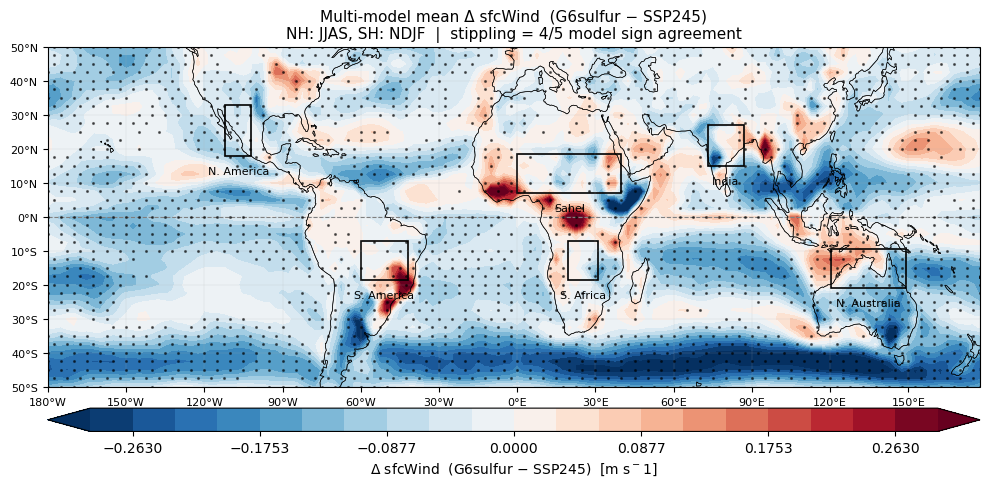

Figure saved → sfcWind_G6sulfur20212100_minus_SSP24520212100.png
Returning → sfcWind_G6sulfur20212100_minus_SSP24520212100


In [11]:
delta_mean, stipple_mask = compute_regional_map(
    all_results,
    exp1=EXP1,
    exp2=EXP2,
    agreement_threshold=4,   # 3/4 models
    save_fig=True
)